# Radar in a Single Homogeneous Medium: Free-Space

In the context of wave propagation, a homogeneous free-space is the simplest medium to solve for. 
As such, in this notebook, we present a step-by-step guide for setting up simple problems with `elfe3D_GPR`. 

We demonstrate how to use the `Python` wrapper to set up problems that are solved by the `Fortran` core of `elfe3D_GPR`. 
Once solved, we illustrate some simple functions to post-process and visualize field results that are also a part 
of the Python wrapper.

## 1. Imports

The `Python` wrapper for `elfe3D_GPR` is simply `elfe3d_gpr_io`. It is installed from the repository root using `pip install -e .`. Once installation of the Fortran core as well as this IO wrapper is complete using the steps mentioned here (), we can proceed with importing and setting up the IO tools

In [1]:
%matplotlib inline
import os
from pathlib import Path

# elfe3D_GPR inputs and model building
from elfe3d_gpr_io.inputs.survey import GPRSurvey

# elfe3D_GPR integrated mesh building and solver execution
from elfe3d_gpr_io.runner import ProjectPaths, run_tetgen, run_solver

# elfe3D_GPR output reading, postprocessing, and visualization
from elfe3d_gpr_io.outputs.fieldreader import AnalyticalLoader, ElfeLoader
from elfe3d_gpr_io.outputs.postprocess import field_error, error_stats
from elfe3d_gpr_io.outputs.visualize   import (ReceiverLinePlot, 
                                               ReceiverLineErrorPlot,
                                               ReceiverLineCombined,
                                               ErrorHistogramPlot)

F:\Projects\EMGeoInversion\elfe3D_GPR\io\runner.py:52: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if self.exec_rel is "":


## 2. Paths and runtime configuration

As the current workflow of `elfe3D_GPR` involves:

1. A `Fortran` core solver,
2. `tetgen` meshing library, and
3. A `Python` IO wrapper,

it is essential to ensure that all three systems are found by the system and work together regardless of their own individual install path locations. As such, the `ProjectPaths` class (and hence the complete `runner` script) was created. 

`Windows` users can install `elfe3D_GPR` in their `WSL` (Windows Subsystems for Linux) while `Linux` users have native support.

### Linux-only and WSL guidance

- Linux-only users should set `use_wsl=False`, install `tetgen` and `mumps` in Linux, and ensure `elfe3d_gpr` is executable at `paths.exec_path()`.
- WSL users should keep `use_wsl=True`, install `tetgen` inside WSL, and rely on `runner.py` to convert Windows `Path` values to `/mnt/...` paths.
- For both workflows, verify `survey.io.poly_file` and `survey.io.base_dir` are correct before running the solver.
- Advanced users can use `run_custom_command(paths, command, cwd=..., use_wsl=...)` to override command execution.

In [ ]:
MASTER_PATH = Path(r"..\elfe3D_GPR").resolve() # Base path variable, optional. .resolve() converts the relative path to the full path.

paths = ProjectPaths(
    master_dir = MASTER_PATH,   # Path where the elfe3D_GPR executable is located. Currently it is the same as repository root.
    exec_rel   = "",            # Relative path to find the executable. With the default installation it exists in the repository root, hence an empty string.
    use_wsl    = True,          # False if running the notebook from native Linux.
)

# Prints to verify that the paths are correct.
# print('Solver root:', MASTER_PATH)
# print('Executable:', paths.exec_path())


## 3: Generating the Geophysical Model using the Python I/O Wrapper

In this step we start building our geophysical model. As the example model here only has free-space, the focus of this example is to show the various input choices that exist to alter how the model is setup and run.

### IO class and functions

For simplicity, the `GPRSurvey` class was written to collect all relevant input information that will be used to create the simulation, such as the domain extents, materials, source, receivers, solver settings, and PML configuration.

Its `build()` function accepts all simulation input, and its `generate()` function generates most of the needed `elfe3D_GPR` input files. The rest of the input files are mesh files that will be created by `tetgen` in the next step.

### Physical conventions and modelling considerations

The coordinate system followed by `elfe3D_GPR` is the conventional cartesian system, with the air-ground interface at $z = 0$, upwards being $+z$-axis, while downwards into ground being $-z$-axis.

The current I/O implementation requires at least one earth layer, so the layer is set to match air properties exactly.


In [ ]:
# Frequency and wavelength definitions (optional to define before building the GPR survey information).

f    = 100e6        # only one frequency to be simulated: can be extended to a list in a single run.
wave = 3e8 / f      # free-space wavelength for the same frequency, a simple approximate to manage dimensions and PML variables.


# Building the survey information using the `GPRSurvey.build()` function.

survey = GPRSurvey.build(

    # Name of the experiment, will also be used to create file and folder names for I/O.
    experiment_name = 'air_only', 

    # Base directory for the input and output files. The input files get created in base_dir/in, while outputs get created in base_dir/out_{experiment_name}.
    base_dir        = MASTER_PATH, 

    # Domain extents [in meters]. x_e and y_e are lateral extents, while z_e is the vertical extent. x_e currently has 1 m extra  to keep all receivers. 
    # wave/10 is a padding around the source to ensure enough of the near-field is captured before the PML starts.
    # As can be noticed, the domain is a very small box around the source and receivers, 
    # which is a strength from dense meshing from unstructured FEM.
    x_e = [-wave/10, 1 + wave/10],  
    y_e = [-wave/10,     wave/10],
    z_e = [-wave/10,     wave/10],

    # Material definition (air/free-space): Currently the air parameters can also be modified (but the flexibility might be removed in the future versions).
    air_eps_r = 1.0,      
    air_sigma = 1e-16,

    # Material definitions (layers of earth): Currently only one layer is needed (and that of free-space).
    # Layers can be simultaneously defined in lists as shown below, where each entry of the list corresponds to one layer.
    # These layer variables should have the same number of entries.
    layer_thicknesses = [wave/10],  # thin dummy layer required by current implementation (will be made more flexible in future versions).
    layer_eps_r       = [1.0],      # same as air
    layer_sigma       = [1e-16],    # same as air
    layer_mu_r        = [1.0],      # Non-magnetic
    layer_sigma_m     = [0.0],      # No magnetic losses

    # Source dipole definition: Currently only one source definition is possible, but the same source can have multiple frequencies. 
    # This is to allow wide-band simulations, like a real-world GPR system.
    # Note that with a wide spectrum, one mesh file with one specific discretization could struggle with accuracy.
    # In the thesis work () @TODO, it was studied how many `blocks` does a wide-band spectrum need to be divided into to allow accurate results over the 
    # entire spectrum.
    f_list              = [f],                  # List of frequencies.
    antenna_position    = [0.0, 0.0, 0.025],    # [x, y, z], 25 mm above the surface.
    source_type         = 6,                    # 6 corresponds to a flexible dipole definition. Use as default.
    current_direction   = 1,                    # 1 corresponds to x-direction, 2 to y-direction, and 3 to z-direction.
    num_segments        = 1,                    # Number of segments to divide the dipole source into. Gives more meshing flexibility, but not required for now.
    s_f                 = 250,                  # Source factor: How large the source dipole length is compared to free-space wavelength of the first frequency in the `f_list`.
    box_present         = False,                # @TODO: <To be deprecated> Box of fine mesh around the source: The feature was tested during the thesis (), but results were not promising.
    bh_f                = 1.0,                  # @TODO: <To be deprecated> Box factor: same as above.
    box_x               = [-1.0, 1.0],          # @TODO: <To be deprecated>
    # for `source_type`: Other types have fixed orientations including loops of current (from the original elfe3D code).

    # Receiver points definition: 
    # In lieu with GPR surveys, you can define receivers in three typical directions from the source direction:
    # 1) endfire (inline): location along the same direction as the source dipole axis
    # 2) broadside: location along the direction perpendicular to the source dipole axis
    # 3) oblique (at 45 degrees to the source)
    num_receivers_inline  = 48,
    num_receivers_endfire = 0, # @TODO: Fix naming of receiver lines.
    num_receivers_oblique = 0,

    # Solver parameters definition: elfe3D_GPR uses MUMPS to solve the system of equations once the FEM system is assembled.
    # The following parameters are passed to MUMPS solver directly. You can refer to the MUMPS documentation for 
    # more details on these parameters: () @TODO
    solver_type      = 2,
    max_ref_steps    = 0,
    max_unknowns     = 5_000_000,
    accuracy_tol     = 3e-5,
    output_fields_vtk = 1,

    # PML definition: The Perfectly Matched layer (PML) used in elfe3D_GPR is the Uniaxial PML with an "Exact Reciprocal Decay" as the default type. 
    # You can find more details on the specifics of the PML implementation and the specific decay function here () @TODO.
    # Only 1 layer of heterogeneously distributed mesh elements is needed due to the Exact Reciprocal Decay implementation.
    num_pml_layers      = 1,        # Number of PML layers.
    pml_layer_thickness = wave/10,  # Thickness of the PML layer. With elfe3D_GPR, the PML layer can be very thin.
    pml_type            = 'lin',    # @TODO <To be deprecated>
    pml_decay_type      = 1,        # PML decay type: 1 corresponds to "Exact Reciprocal Decay", default and recommended. Others mentioned here () @TODO.

    least_samples_per_wavelength = 40,  # Dictates how big the mesh element edge lengths are at a maximum per region. Recommended at least 10.
)

# Once the survey information is built into the right structures, the `survey.generate()` function creates the input files for the meshing and solver steps.
survey.generate()

# Prints to verify that the paths are correct for the input files generated by the I/O wrapper.
# print('poly :', survey.io.poly_file)
# print('inputs:', survey.io.input_dir)


odepths: [np.float64(0.01875), np.float64(0.01875)]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
[0.0]
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_air_only.poly
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\elfe3D_input.txt
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\source.txt
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\regionparameters.txt
Input generation complete.


## 2: Mesh generation with TetGen

TetGen converts the generated `.poly` geometry into a tetrahedral mesh.
This mesh is required by the FEM solver to discretize the air-only domain.


In [4]:
# TetGen reads the generated .poly geometry and builds the mesh.
# The mesh is stored alongside the input files in the survey input directory.
run_tetgen(paths, survey.io.poly_file)


── TetGen ────────────────────────────────────────────
   cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/in && /usr/bin/tetgen -pq1.2kAaen GPR_model_air_only.poly

Opening GPR_model_air_only.poly.
Delaunizing vertices...
Delaunay seconds:  0.002467
Creating surface mesh ...
Surface mesh seconds:  0.001179
Constrained Delaunay...
Constrained Delaunay seconds:  0.002015
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000145
Refining mesh...
Refinement seconds:  1.541
Optimizing mesh...
Optimization seconds:  0.077971

Writing GPR_model_air_only.1.node.
Writing GPR_model_air_only.1.ele.
Writing GPR_model_air_only.1.face.
Writing GPR_model_air_only.1.edge.
Writing GPR_model_air_only.1.vtk.
Writing GPR_model_air_only.1.neigh.

Output seconds:  1.20018
Total running seconds:  2.82506

Statistics:

  Input points: 226
  Input facets: 118
  Input segments: 329
  Input holes: 0
  Input regions: 36

  Mesh points: 76243
  Mesh tetrahedra: 

## 3: Run the Fortran solver

This step launches the compiled solver executable using the configured `ProjectPaths`.
The solver reads the FEM input files from the survey folder and writes field results to the output directory.


In [5]:
# Run the Fortran solver. The solver reads the prepared input files
# and writes electric field output to the survey output directory.
run_solver(paths, survey)


── elfe3d_gpr ────────────────────────────────────────
   wsl bash -c cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR && /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/elfe3d_gpr

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions
Your input meshfile is called
 in/GPR_model_air_only.                            
Your mesh has
       76243 Nodes
      452570 Elements
      536922 Edges (dof)
*************************************
Assembling connectivity arrays
Calcul

## 4: Load solver results

The solver output is stored in the survey output directory.
`ElfeLoader` reads the electric field receiver-line file and converts it to the endfire result format used for plotting and comparison.


In [6]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
print('reading:', result_txt)

# Load the receiver-line electric field result from the solver output.
# Here we use the same number of endfire receivers as defined above.
ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D  air_only',
    num_endfire = 48,   # matches num_receivers_inline above
).endfire()

print(f'r : {ef.r.min():.3f} - {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_air_only\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## 5: Analytical reference for the air-only case

This reference dataset is a semi-analytical solution for a homogeneous air domain at 100 MHz.
The comparison helps validate the solver output against a known analytical result.


In [7]:
# Half-space analytical quadrature reference (eps_r = 1 everywhere)
ANALYTICAL_DIR = r'F:\Projects\EMGeoInversion\elfe3D_GPR\data\data_semi_analytical'

analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_air_100MHz_NR.csv'),
    label='analytical',
).endfire()


## 6: Compare computed field to analytical reference

This plot shows the computed endfire electric field together with the analytical reference.
A close match indicates the solver correctly reproduces the air-only response.


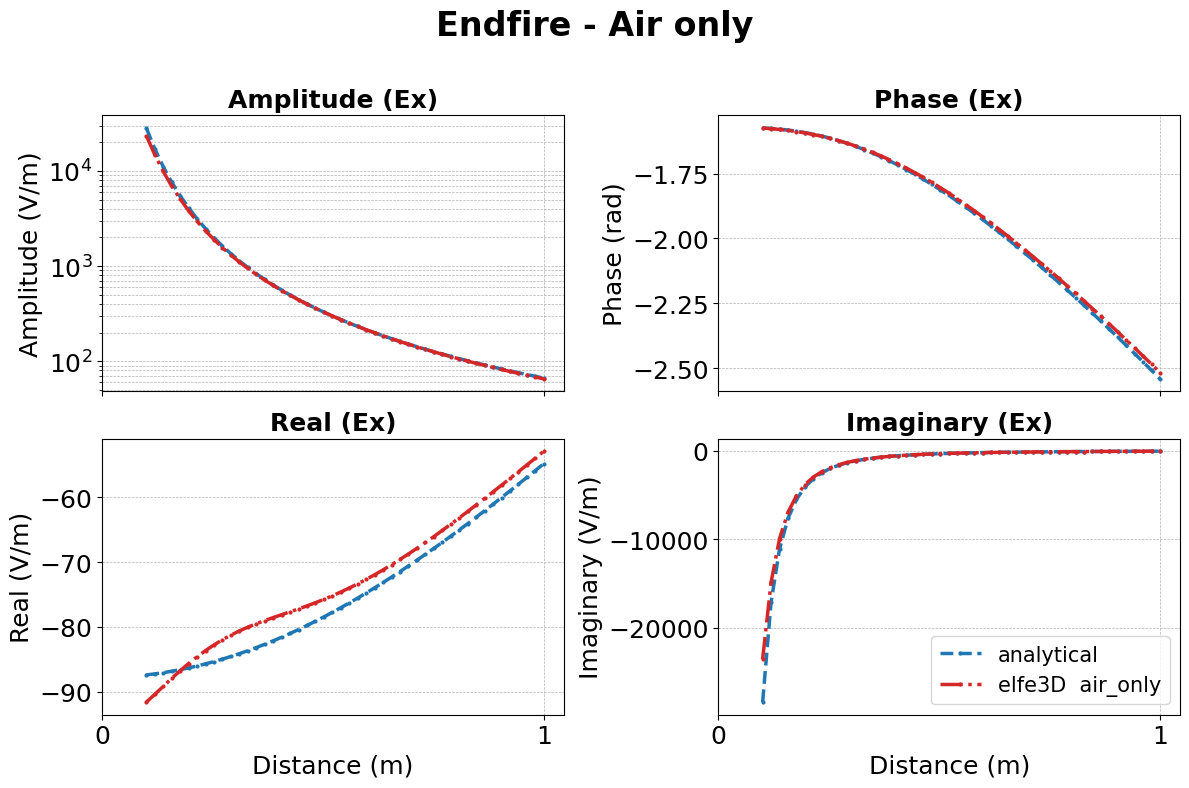

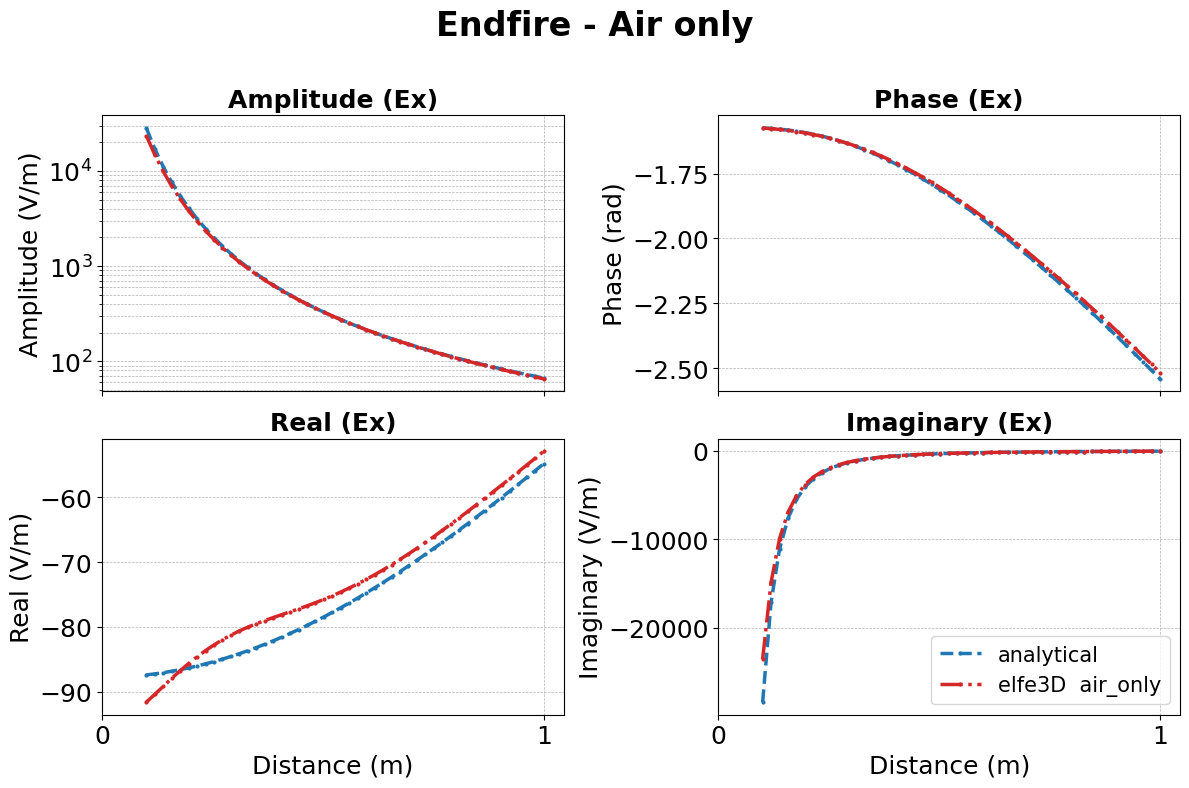

In [8]:
ReceiverLinePlot([analytical, ef],).plot(suptitle='Endfire - Air only')


## Error plot and quality check

This plot highlights the difference between the computed result and the analytical reference.
Small error magnitudes indicate good solver agreement in the air-only case.


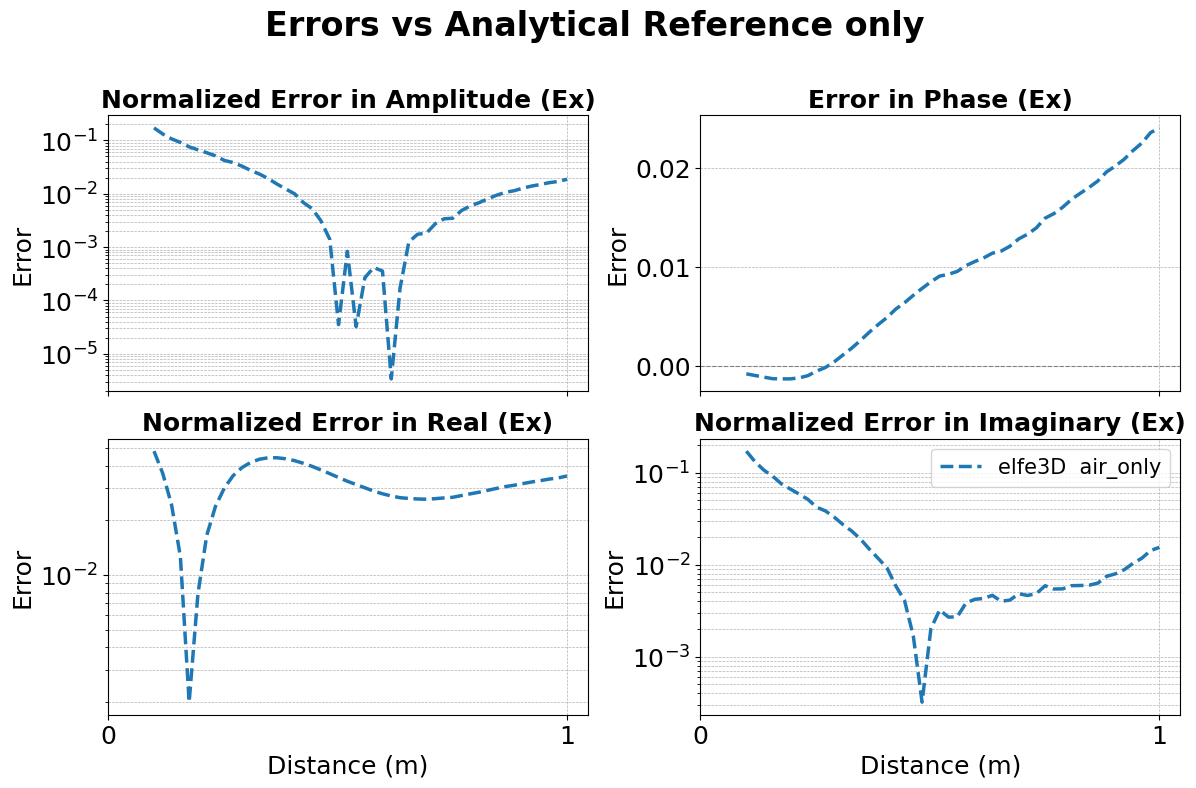

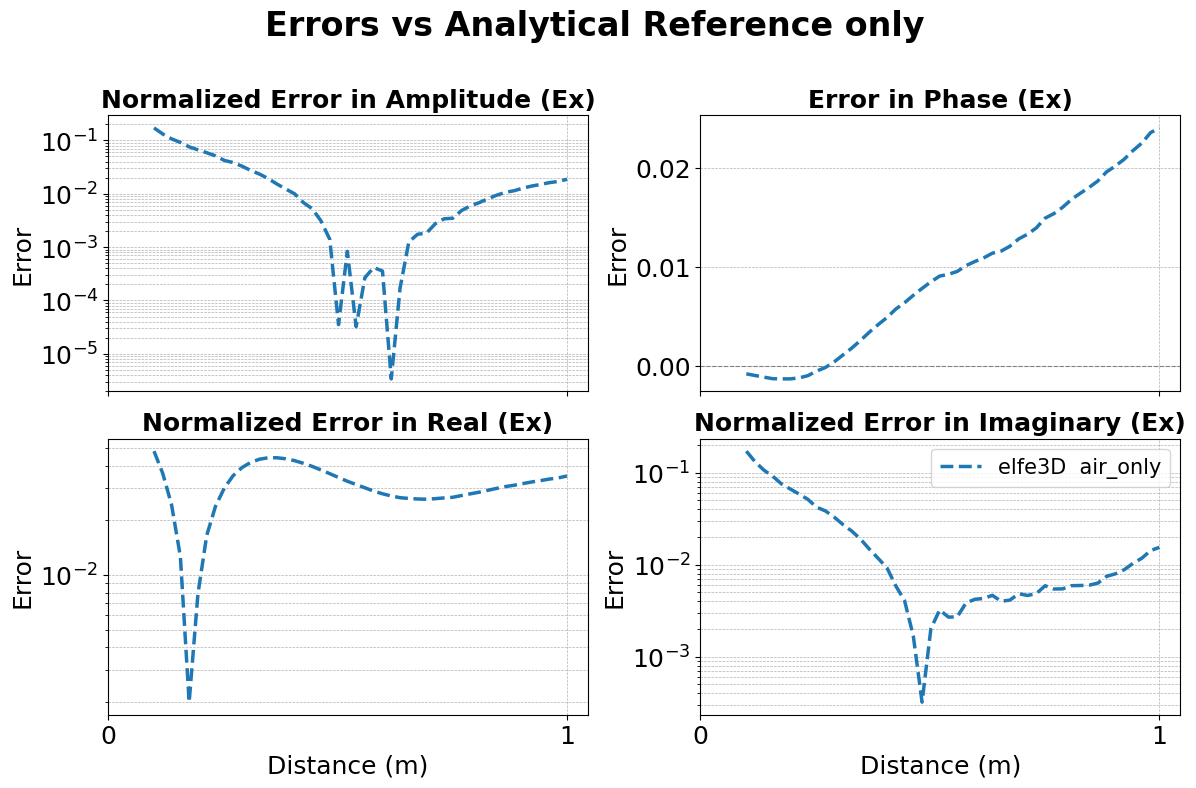

In [9]:
ReceiverLineErrorPlot([ef], reference=analytical).plot(suptitle='Errors vs Analytical Reference only')

## Combined field and error plot

Here we overlay the field and error visualizations to inspect the results in one view.
This helps confirm whether the error structure is consistent across receivers.


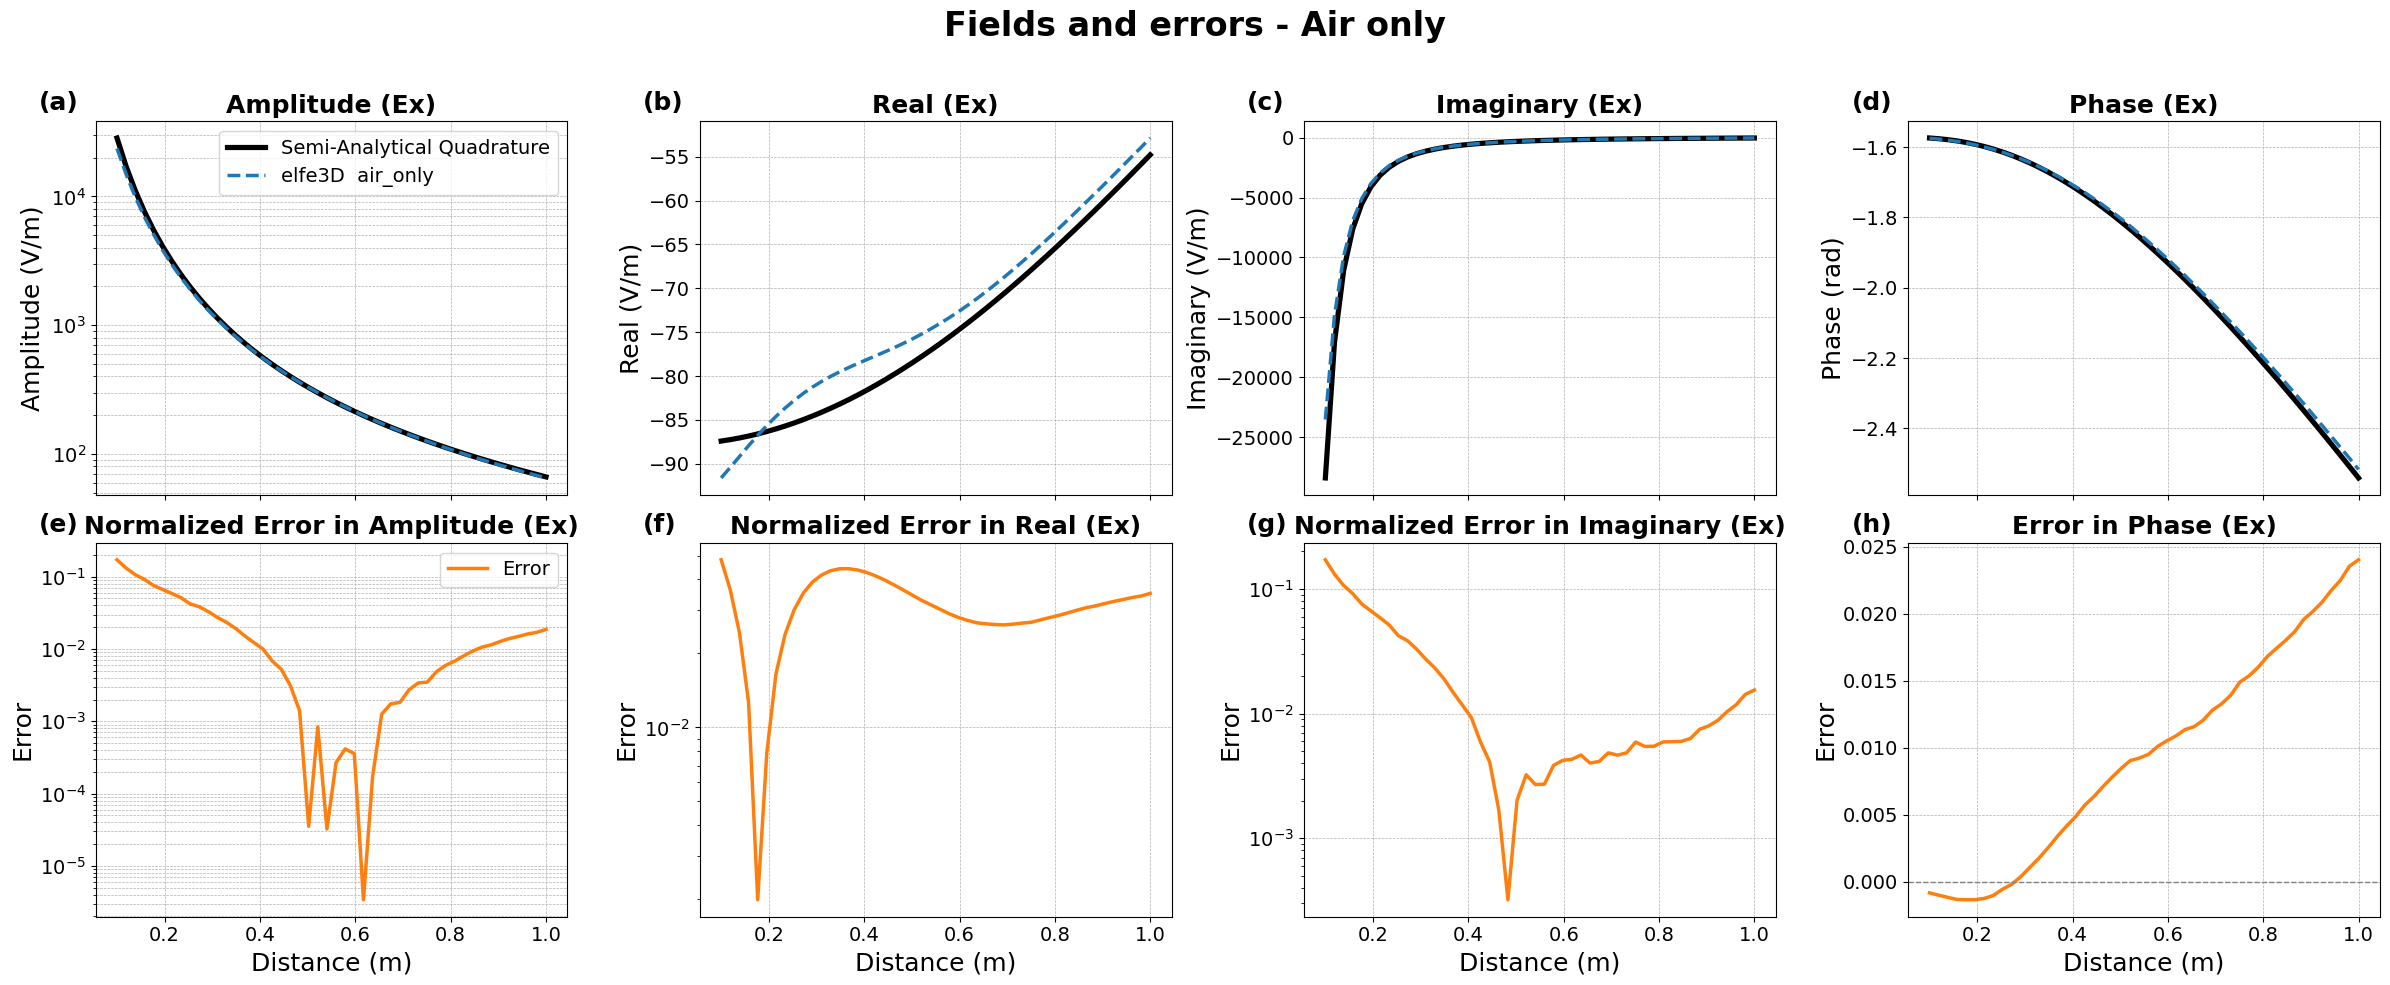

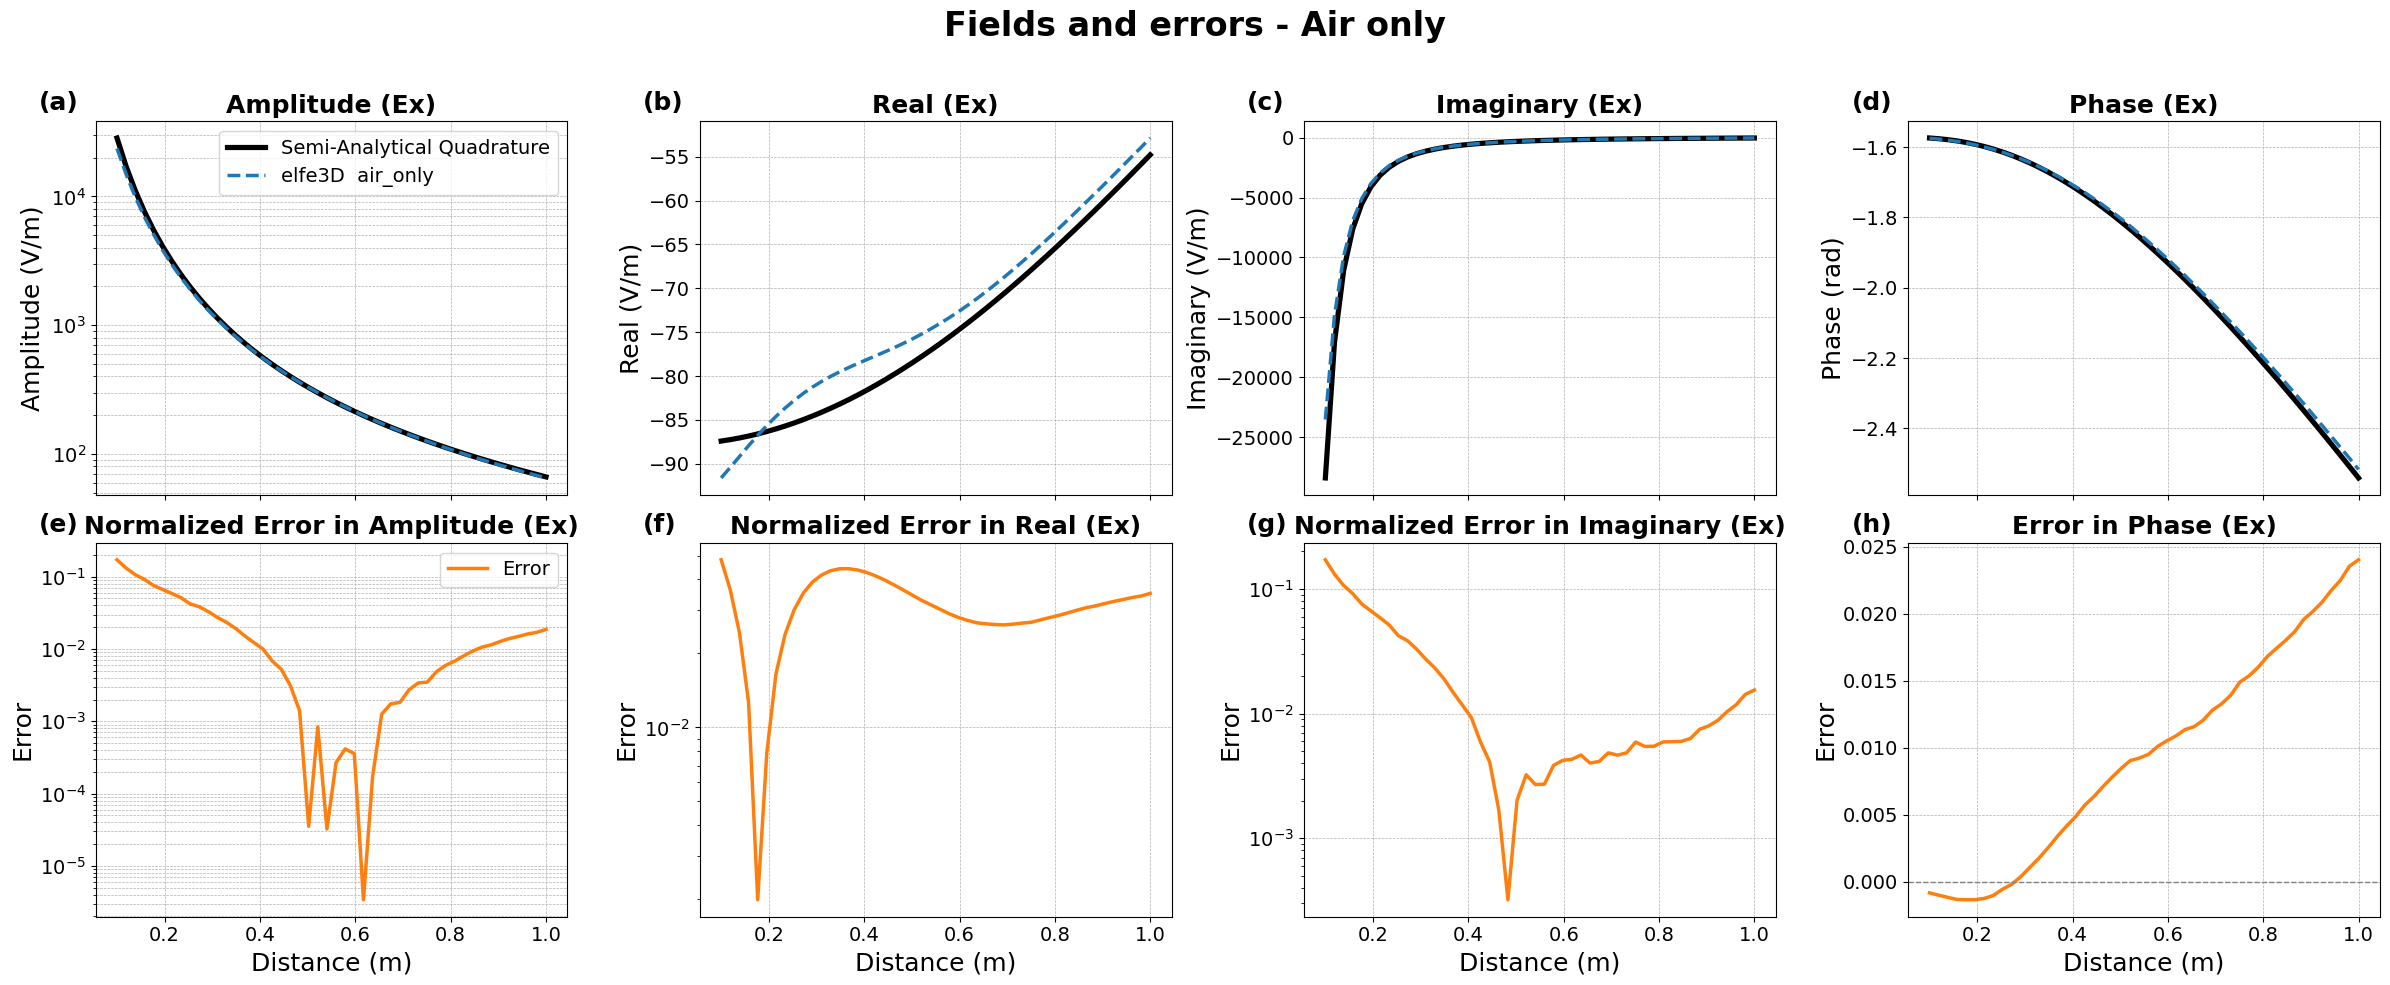

In [10]:
ReceiverLineCombined(ef, analytical).plot(suptitle='Fields and errors - Air only')


## Error distribution histogram

The histogram shows the distribution of errors relative to the analytical reference.
It is useful for identifying systematic bias or large outliers in the computed field.


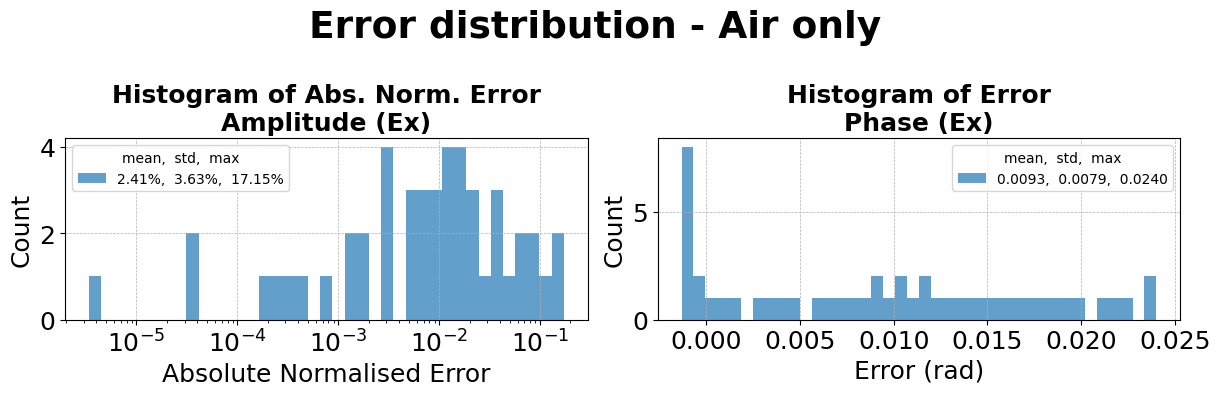

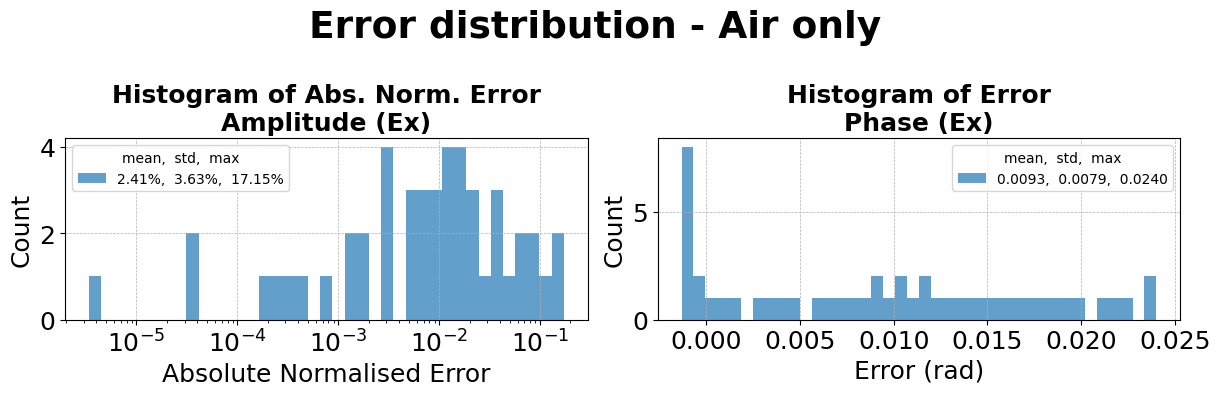

In [11]:
ErrorHistogramPlot([ef], reference=analytical).plot(suptitle='Error distribution - Air only')

## Numerical error summary

This summary computes mean, standard deviation, and maximum error for amplitude, phase, real, and imaginary components.
These statistics quantify agreement with the analytical solution.


In [12]:
qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
print(f'\n── {ef.label} ──')
for qi, name in enumerate(qty_names):
    err = field_error(analytical, ef, qi)
    m, s, mx = error_stats(err)
    scale, unit = (100, '%') if qi != 1 else (1, 'rad')
    print(f'  {name:12s}:  mean={m*scale:.3f}{unit}  '
          f'std={s*scale:.3f}{unit}  max={mx*scale:.3f}{unit}')



── elfe3D  air_only ──
  Amplitude   :  mean=2.413%  std=3.634%  max=17.151%
  Phase       :  mean=0.009rad  std=0.008rad  max=0.024rad
  Real        :  mean=3.114%  std=0.895%  max=4.807%
  Imaginary   :  mean=2.400%  std=3.621%  max=17.151%


## Conclusions

This notebook demonstrates the core `elfe3D_GPR` workflow for an air-only model.
The solver output is compared to a semi-analytical reference, and the error metrics show how well the computed field matches the expected air response.

Next steps:
- explore the homogeneous-earth example to add material contrast,
- run the two-layered-earth case to validate subsurface layering,
- inspect how receiver geometry affects the field results.
